# Leave-One-Out Cross-Validation Approach

Approach thứ hai cho bài toán quantum kernel recommendation. Khác với Majority Voting (dùng ensemble 14 classifiers), LOOCV đánh giá từng classifier độc lập trên từng fold — mỗi fold để lại đúng 1 dataset làm test.

Ưu điểm: tận dụng tối đa dữ liệu train (N-1 samples), không cần xử lý rare kernels riêng, và cho kết quả deterministic (không phụ thuộc random split). Nhược điểm: chi phí tính toán cao (N folds × 14 classifiers).

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

## Classifiers

Cùng bộ 14 classifiers như Majority Voting, nhưng ở đây mỗi classifier được đánh giá độc lập — không aggregate qua voting. Kết quả cuối cùng report accuracy của classifier tốt nhất (best single classifier), cho phép so sánh trực tiếp: liệu ensemble (MV) có thực sự tốt hơn best individual classifier (LOOCV) hay không.

In [6]:
CLASSIFIERS = {
    'DT': DecisionTreeClassifier(random_state=42),
    'RF': RandomForestClassifier(n_estimators=10, random_state=42),
    'Ensemble-GB': GradientBoostingClassifier(random_state=42),
    'Ensemble-AB': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42), 
        n_estimators=50, 
        random_state=42,
        algorithm='SAMME'
    ),
    'Ensemble-Bg': BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=10,
        random_state=42
    ),
    'SVM-Linear': SVC(kernel='linear', random_state=42, probability=True),
    'SVM-RBF': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True),
    'SVM-Sigmoid': SVC(kernel='sigmoid', C=1.0, gamma='scale', random_state=42, probability=True),
    'MLP-500': MLPClassifier(hidden_layer_sizes=(500,), max_iter=1000, random_state=42),
    'MLP-100-100-100': MLPClassifier(hidden_layer_sizes=(100,100,100), max_iter=1000, random_state=42),
    'kNN': KNeighborsClassifier(n_neighbors=5),
    'NearestCentroid': NearestCentroid(),
    'NaiveBayes': GaussianNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
}

print(f"Classifiers: {len(CLASSIFIERS)}")

Classifiers: 14


## Load Data

Load 3 file CSV đã tạo từ file Quantum Learning Procedure:
- `synthesis_df`: 24 complexity metrics + Best_Kernel label (features + Task-A label)
- `taskb_labels`: expanded labels cho Task-B (mỗi dataset → nhiều tied kernels)

Metric columns được tách tự động bằng cách loại bỏ cột `Best_Kernel`.

In [7]:
print("="*70)
print("LOAD DATA")
print("="*70)

df = pd.read_csv("results/synthesis_df with load_data.csv", index_col=0)
df_tied = pd.read_csv("results/taskb_labels with load_data.csv")
df_tied = df_tied.set_index('Dataset')

metric_columns = [c for c in df.columns if c != 'Best_Kernel']

print(f"Datasets: {len(df)}")
print(f"Metrics: {len(metric_columns)}")
print(f"Task-A samples: {len(df)}")
print(f"Task-B samples: {len(df_tied)}")

LOAD DATA
Datasets: 200
Metrics: 24
Task-A samples: 200
Task-B samples: 483


## Task-A: LOOCV Evaluation

`evaluate_task1a`: đánh giá 1 classifier trên Task-A bằng LeaveOneOut. Mỗi fold:
- Train trên N-1 datasets, test trên 1 dataset còn lại
- StandardScaler fit trên train, transform trên test (chỉ khi dùng nhiều features)
- Prediction đúng khi pred == label duy nhất (best kernel)

Trả về accuracy = tỷ lệ datasets được dự đoán đúng / tổng N datasets.## Task-A

In [8]:
def evaluate_task1a(X, y, classifiers, scale_features=True, desc="Task-A"):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    loo = LeaveOneOut()
    results = {}
    
    for clf_name, clf in tqdm(classifiers.items(), desc=desc):
        scores = []
        
        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
            
            if scale_features and X.shape[1] > 1:
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)
            
            try:
                clf_clone = clf.__class__(**clf.get_params())
                clf_clone.fit(X_train, y_train)
                pred = clf_clone.predict(X_test)
                scores.append(1 if pred[0] == y_test[0] else 0)
            except:
                scores.append(0)
        
        results[clf_name] = {
            'accuracy': np.mean(scores),
            'std': np.std(scores),
            'correct': sum(scores),
            'total': len(scores)
        }
    
    return results

## Task-B: LOOCV Evaluation

`evaluate_task1b`: khác biệt quan trọng so với Task-A ở cách xây dựng tập train cho mỗi fold.

Với mỗi fold (test = dataset i):
- Tập train được **expand** từ N-1 datasets còn lại: mỗi dataset đóng góp nhiều samples ứng với các tied kernels của nó (tra cứu từ `df_tied`)
- LabelEncoder được fit **riêng cho mỗi fold** vì tập kernels có thể khác nhau khi loại bỏ dataset test
- Prediction đúng khi pred nằm trong tập valid kernels của dataset test

Lưu ý: không có data leakage vì expansion chỉ áp dụng trên train, và test luôn là 1 dataset hoàn toàn tách biệt.

In [9]:
def evaluate_task1b(X, df_tied, dataset_names, classifiers, scale_features=True, desc="Task-B"):
    n_datasets = len(dataset_names)
    
    valid_kernels_lookup = {}
    for dataset in dataset_names:
        valid_kernels_lookup[dataset] = df_tied.loc[
            df_tied.index == dataset, 'Best_Kernel'
        ].tolist()
    
    results = {}
    
    for clf_name, clf in tqdm(classifiers.items(), desc=desc):
        scores = []
        
        for test_idx, test_dataset in enumerate(dataset_names):
            X_train_list = []
            y_train_list = []
            
            for train_idx, train_dataset in enumerate(dataset_names):
                if train_dataset == test_dataset:
                    continue
                
                valid_kernels = valid_kernels_lookup[train_dataset]
                for kernel in valid_kernels:
                    X_train_list.append(X[train_idx])
                    y_train_list.append(kernel)
            
            X_train = np.array(X_train_list)
            y_train = np.array(y_train_list)
            
            # Encode
            le = LabelEncoder()
            y_train_encoded = le.fit_transform(y_train)
            
            if len(np.unique(y_train_encoded)) < 2:
                scores.append(0)
                continue
            
            if scale_features and X.shape[1] > 1:
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X[test_idx:test_idx+1])
            else:
                X_train_scaled = X_train
                X_test_scaled = X[test_idx:test_idx+1]
            
            valid_kernels_test = valid_kernels_lookup[test_dataset]
            
            try:
                clf_clone = clf.__class__(**clf.get_params())
                clf_clone.fit(X_train_scaled, y_train_encoded)
                pred_encoded = clf_clone.predict(X_test_scaled)
                pred_kernel = le.inverse_transform(pred_encoded)[0]
                
                is_correct = pred_kernel in valid_kernels_test
                scores.append(1 if is_correct else 0)
            except:
                scores.append(0)
        
        results[clf_name] = {
            'accuracy': np.mean(scores),
            'std': np.std(scores),
            'correct': sum(scores),
            'total': n_datasets
        }
    
    return results

### Lọc features và label riêng

In [10]:
dataset_names = df.index.tolist()
y = df['Best_Kernel'].values
X_all = df[metric_columns].values  

all_results = {}

In [11]:
print(metric_columns)

['f1', 'f1v', 'f2', 'f3', 'f4', 'l1', 'l2', 'l3', 'n1', 'n2', 'n3', 'n4', 't1', 'lsc', 'density', 'clsCoef', 'hubs', 't2', 't3', 't4', 'c1', 'c2', 'kolmogorov', 'intrinsic']


### Task-A: Single Metric

Chạy LOOCV cho từng metric đơn lẻ × 14 classifiers. Kết quả là bảng 24×14 = 336 combinations, từ đó chọn best (metric + classifier) cho Task-A.

Khác với MV (report best metric across ensemble), LOOCV report best (metric, classifier) pair — cho phép xác định classifier nào phù hợp nhất với từng metric.

In [12]:
print("\n" + "="*70)
print("CASE 1: SINGLE METRIC - TASK-A")
print("="*70)

single_metric_task1a = []

for metric in tqdm(metric_columns, desc="Single Metric Task-A"):
    X_single = df[[metric]].values
    results = evaluate_task1a(X_single, y, CLASSIFIERS, scale_features=False, desc="")
    
    for clf_name, res in results.items():
        single_metric_task1a.append({
            'Metric': metric,
            'Classifier': clf_name,
            'Accuracy': res['accuracy'],
            'Correct': res['correct'],
            'Total': res['total']
        })

df_1a_single = pd.DataFrame(single_metric_task1a)
best_single_1a = df_1a_single.loc[df_1a_single['Accuracy'].idxmax()]
print(f"\n Best Single Metric (Task-A): {best_single_1a['Metric']} + {best_single_1a['Classifier']} = {best_single_1a['Accuracy']:.4f}")

all_results['single_metric_task1a'] = df_1a_single


CASE 1: SINGLE METRIC - TASK-A


Single Metric Task-A: 100%|██████████| 24/24 [2:17:06<00:00, 342.76s/it]


 Best Single Metric (Task-A): n4 + NaiveBayes = 0.6750


### Task-B: Single Metric

Tương tự Task-A Single Metric nhưng dùng cơ chế đánh giá Task-B (expand train, valid kernels check).

In [13]:
print("\n" + "="*70)
print("CASE 2: SINGLE METRIC - TASK-B")
print("="*70)

single_metric_task1b = []

for metric in tqdm(metric_columns, desc="Single Metric Task-B"):
    X_single = df[[metric]].values
    results = evaluate_task1b(X_single, df_tied, dataset_names, CLASSIFIERS, scale_features=False, desc="")
    
    for clf_name, res in results.items():
        single_metric_task1b.append({
            'Metric': metric,
            'Classifier': clf_name,
            'Accuracy': res['accuracy'],
            'Correct': res['correct'],
            'Total': res['total']
        })

df_1b_single = pd.DataFrame(single_metric_task1b)
best_single_name = df_1b_single.iloc[0]['Metric']
best_single_1b = df_1b_single.loc[df_1b_single['Accuracy'].idxmax()]
print(f"\n Best Single Metric (Task-B): {best_single_1b['Metric']} + {best_single_1b['Classifier']} = {best_single_1b['Accuracy']:.4f}")

all_results['single_metric_task1b'] = df_1b_single


CASE 2: SINGLE METRIC - TASK-B


Single Metric Task-B: 100%|██████████| 24/24 [2:28:05<00:00, 370.22s/it]


 Best Single Metric (Task-B): n4 + MLP-100-100-100 = 0.7150


### Task-A: All Metrics

Chạy LOOCV với toàn bộ 24 metrics × 14 classifiers. StandardScaler được bật (scale_features=True) vì các metrics có scale rất khác nhau.

In [14]:
print("\n" + "="*70)
print("CASE 3: ALL METRICS (24) - TASK-A")
print("="*70)

results_all_1a = evaluate_task1a(X_all, y, CLASSIFIERS, scale_features=True, desc="All Metrics Task 1-A")

all_metrics_task1a = []
for clf_name, res in results_all_1a.items():
    all_metrics_task1a.append({
        'Classifier': clf_name,
        'Accuracy': res['accuracy'],
        'Correct': res['correct'],
        'Total': res['total']
    })

df_1a_all = pd.DataFrame(all_metrics_task1a).sort_values('Accuracy', ascending=False)
best_all_1a = df_1a_all.iloc[0]
print(f"\n Best All Metrics (Task-A): {best_all_1a['Classifier']} = {best_all_1a['Accuracy']:.4f}")

all_results['all_metrics_task1a'] = df_1a_all


CASE 3: ALL METRICS (24) - TASK-A


All Metrics Task 1-A: 100%|██████████| 14/14 [09:24<00:00, 40.36s/it]


 Best All Metrics (Task-A): MLP-500 = 0.7350


### Task-B: Single Metric

Tương tự Task-A Single Metric nhưng dùng cơ chế đánh giá Task-B (expand train, valid kernels check).

In [15]:
print("\n" + "="*70)
print("CASE 4: ALL METRICS (24) - TASK-B")
print("="*70)

results_all_1b = evaluate_task1b(X_all, df_tied, dataset_names, CLASSIFIERS, scale_features=True, desc="All Metrics Task 1-B")

all_metrics_task1b = []
for clf_name, res in results_all_1b.items():
    all_metrics_task1b.append({
        'Classifier': clf_name,
        'Accuracy': res['accuracy'],
        'Correct': res['correct'],
        'Total': res['total']
    })

df_1b_all = pd.DataFrame(all_metrics_task1b).sort_values('Accuracy', ascending=False)
best_all_1b = df_1b_all.iloc[0]
print(f"\n Best All Metrics (Task-B): {best_all_1b['Classifier']} = {best_all_1b['Accuracy']:.4f}")

all_results['all_metrics_task1b'] = df_1b_all


CASE 4: ALL METRICS (24) - TASK-B


All Metrics Task 1-B:   0%|          | 0/14 [00:00<?, ?it/s]

All Metrics Task 1-B: 100%|██████████| 14/14 [11:25<00:00, 48.98s/it] 


 Best All Metrics (Task-B): MLP-100-100-100 = 0.7850


### Save Results for Plotting

Tổng hợp kết quả: với mỗi metric, chỉ giữ lại classifier đạt accuracy cao nhất (best config per metric). Thêm row ALL_METRICS để so sánh trực tiếp trong cùng 1 bảng/biểu đồ.

LOOCV không có std (deterministic), nên Std_Acc = 0.0 cho tất cả.

In [16]:
best_per_metric_1a = (
    df_1a_single
    .sort_values('Accuracy', ascending=False)
    .drop_duplicates(subset='Metric', keep='first')
    .rename(columns={'Accuracy': 'Mean_Acc'})
)
best_per_metric_1a['Std_Acc'] = 0.0

best_all_1a = df_1a_all.sort_values('Accuracy', ascending=False).iloc[0]
all_row_1a = pd.DataFrame([{
    'Metric': 'ALL_METRICS',
    'Classifier': best_all_1a['Classifier'],
    'Mean_Acc': best_all_1a['Accuracy'],
    'Std_Acc': 0.0,
    'Correct': best_all_1a['Correct'],
    'Total': best_all_1a['Total']
}])
loocv_1a = pd.concat([best_per_metric_1a, all_row_1a], ignore_index=True)
loocv_1a = loocv_1a.sort_values('Mean_Acc', ascending=False).reset_index(drop=True)

best_per_metric_1b = (
    df_1b_single
    .sort_values('Accuracy', ascending=False)
    .drop_duplicates(subset='Metric', keep='first')
    .rename(columns={'Accuracy': 'Mean_Acc'})
)
best_per_metric_1b['Std_Acc'] = 0.0

best_all_1b = df_1b_all.sort_values('Accuracy', ascending=False).iloc[0]
all_row_1b = pd.DataFrame([{
    'Metric': 'ALL_METRICS',
    'Classifier': best_all_1b['Classifier'],
    'Mean_Acc': best_all_1b['Accuracy'],
    'Std_Acc': 0.0,
    'Correct': best_all_1b['Correct'],
    'Total': best_all_1b['Total']
}])
loocv_1b = pd.concat([best_per_metric_1b, all_row_1b], ignore_index=True)
loocv_1b = loocv_1b.sort_values('Mean_Acc', ascending=False).reset_index(drop=True)

# ── Save ─────────────────────────────────────────────────────
loocv_1a.to_csv("results/loocv_task1a_results.csv", index=False)
loocv_1b.to_csv("results/loocv_task1b_results.csv", index=False)

print("Saved:")
print(f"  results/loocv_task1a_results.csv  ({len(loocv_1a)} rows)")
print(f"  results/loocv_task1b_results.csv  ({len(loocv_1b)} rows)")
print()
print("Task 1-A LOOCV preview:")
print(loocv_1a[['Metric', 'Classifier', 'Mean_Acc']].to_string(index=False))
print()
print("Task 1-B LOOCV preview:")
print(loocv_1b[['Metric', 'Classifier', 'Mean_Acc']].to_string(index=False))

Saved:
  results/loocv_task1a_results.csv  (25 rows)
  results/loocv_task1b_results.csv  (25 rows)

Task 1-A LOOCV preview:
     Metric         Classifier  Mean_Acc
ALL_METRICS            MLP-500     0.735
         n4         NaiveBayes     0.675
        f1v                kNN     0.660
         c1                 RF     0.655
         c2                 RF     0.655
         l2                 RF     0.645
         f1                kNN     0.640
         f4    MLP-100-100-100     0.630
         f2    MLP-100-100-100     0.630
         l1            SVM-RBF     0.620
    density            SVM-RBF     0.620
         t3        Ensemble-GB     0.620
         l3    MLP-100-100-100     0.615
         t2                 RF     0.610
         f3    MLP-100-100-100     0.595
         t1            MLP-500     0.590
  intrinsic LogisticRegression     0.580
         t4         SVM-Linear     0.580
       hubs         SVM-Linear     0.580
         n2            SVM-RBF     0.580
         n1    

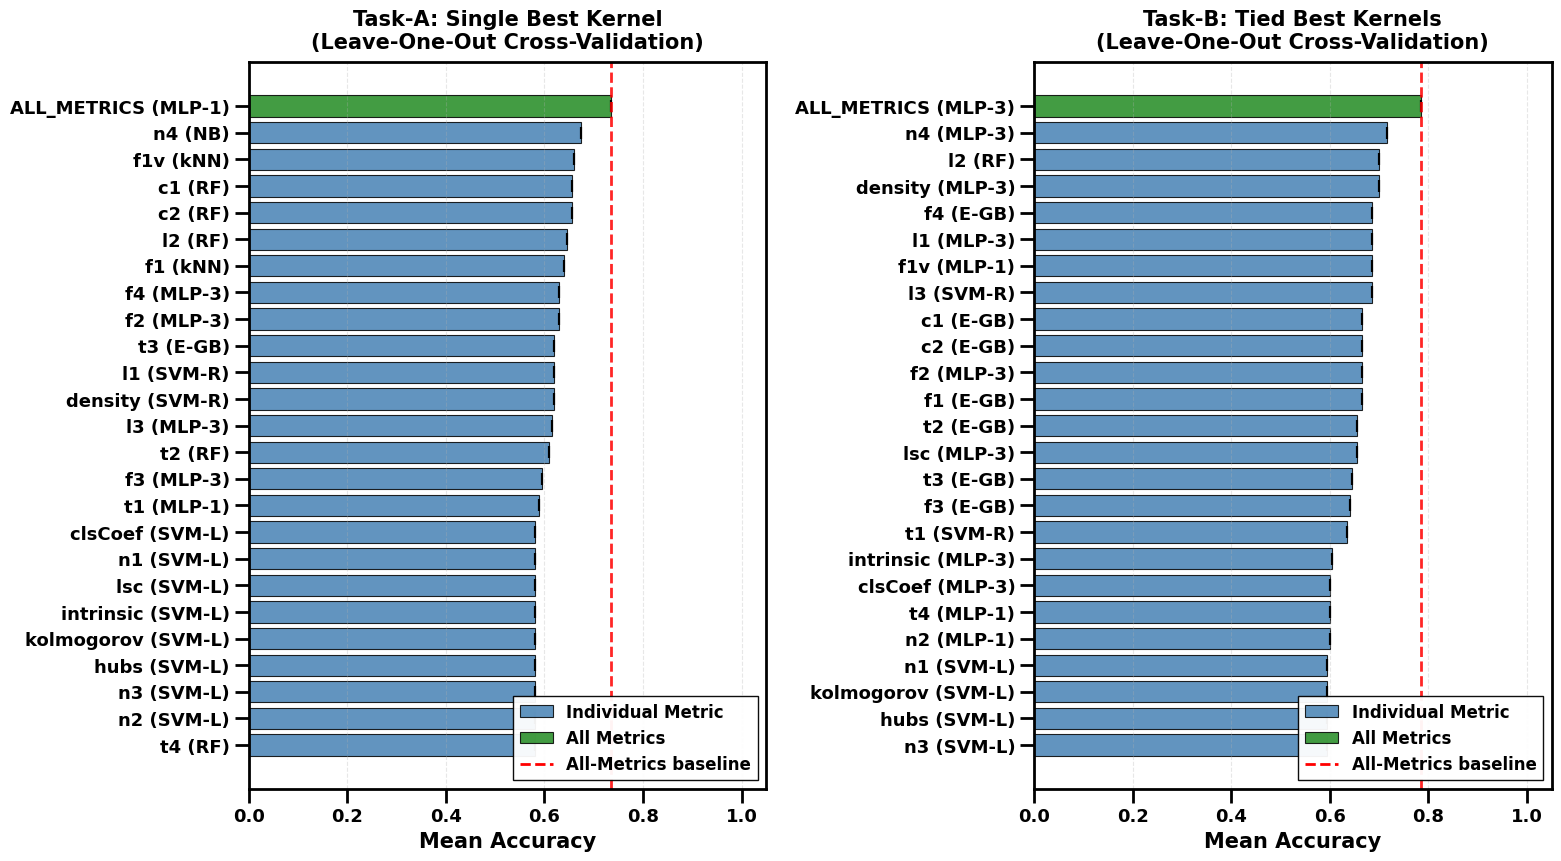


SUMMARY (Best Config per Metric)

Task 1-A:
  Best Single: n4 + NaiveBayes = 0.6750
  ALL_METRICS: MLP-500 = 0.7350

Task 1-B:
  Best Single: n4 + MLP-100-100-100 = 0.7150
  ALL_METRICS: MLP-100-100-100 = 0.7850


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_1a_plot = df_1a_single.loc[
    df_1a_single.groupby('Metric')['Accuracy'].idxmax()
].copy().reset_index(drop=True)
df_1a_plot['Mean_Acc'] = df_1a_plot['Accuracy']
df_1a_plot['Std_Acc']  = 0.0

df_1b_plot = df_1b_single.loc[
    df_1b_single.groupby('Metric')['Accuracy'].idxmax()
].copy().reset_index(drop=True)
df_1b_plot['Mean_Acc'] = df_1b_plot['Accuracy']
df_1b_plot['Std_Acc']  = 0.0

best_all_1a = df_1a_all.loc[df_1a_all['Accuracy'].idxmax()]
best_all_1b = df_1b_all.loc[df_1b_all['Accuracy'].idxmax()]

all_row_1a = pd.DataFrame([{
    'Metric':     'ALL_METRICS',
    'Classifier': best_all_1a['Classifier'],
    'Mean_Acc':   best_all_1a['Accuracy'],
    'Std_Acc':    0.0
}])

all_row_1b = pd.DataFrame([{
    'Metric':     'ALL_METRICS',
    'Classifier': best_all_1b['Classifier'],
    'Mean_Acc':   best_all_1b['Accuracy'],
    'Std_Acc':    0.0
}])

df_1a_plot = pd.concat([df_1a_plot, all_row_1a], ignore_index=True)
df_1b_plot = pd.concat([df_1b_plot, all_row_1b], ignore_index=True)

df_1a_plot = df_1a_plot.sort_values('Mean_Acc', ascending=False).reset_index(drop=True)
df_1b_plot = df_1b_plot.sort_values('Mean_Acc', ascending=False).reset_index(drop=True)

all_metrics_1a = {'Mean_Acc': best_all_1a['Accuracy']}
all_metrics_1b = {'Mean_Acc': best_all_1b['Accuracy']}

plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'axes.linewidth': 2.0,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.major.size': 10,
    'ytick.major.size': 10,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
})

COLOR_SINGLE = 'steelblue'
COLOR_ALL    = 'forestgreen'

ABBREV_CLF = {
    'LogisticRegression': 'LR',
    'SVM-Linear': 'SVM-L',
    'SVM-Sigmoid': 'SVM-S',
    'SVM-RBF': 'SVM-R',
    'MLP-100-100-100': 'MLP-3',
    'MLP-500': 'MLP-1',
    'DT': 'DT',
    'NaiveBayes': 'NB',
    'kNN': 'kNN',
    'Ensemble-GB': 'E-GB',
}

def plot_panel(ax, df_plot, all_metrics_row, title):
    colors = [COLOR_ALL if m == 'ALL_METRICS' else COLOR_SINGLE
              for m in df_plot['Metric']]

    ax.barh(
        range(len(df_plot)),
        df_plot['Mean_Acc'],
        xerr=df_plot['Std_Acc'],
        color=colors,
        capsize=4,
        alpha=0.85,
        edgecolor='black',
        linewidth=0.8,
        error_kw=dict(elinewidth=1.5, ecolor='black', capthick=1.5)
    )

    ax.set_yticks(range(len(df_plot)))

    ylabels = [
        f"{row['Metric']} ({ABBREV_CLF.get(row['Classifier'], row['Classifier'])})"
        for _, row in df_plot.iterrows()
    ]
    ax.set_yticklabels(ylabels, fontweight='bold')   # fontsize theo rcParams (13)

    ax.set_xlabel('Mean Accuracy', fontweight='bold')
    ax.set_title(title, fontweight='bold', pad=10)

    ax.axvline(
        x=all_metrics_row['Mean_Acc'],
        color='red', linestyle='--', linewidth=2.0,
        alpha=0.85, label='_nolegend_'
    )

    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)   

    patch_single = mpatches.Patch(
        facecolor=COLOR_SINGLE, edgecolor='black', linewidth=0.8,
        alpha=0.85, label='Individual Metric'
    )
    patch_all = mpatches.Patch(
        facecolor=COLOR_ALL, edgecolor='black', linewidth=0.8,
        alpha=0.85, label='All Metrics'
    )
    line_ref = plt.Line2D(
        [], [], color='red', linestyle='--', linewidth=2.0,
        label='All-Metrics baseline'
    )
    ax.legend(
        handles=[patch_single, patch_all, line_ref],
        loc='lower right',
        framealpha=0.95,
        edgecolor='black',
        fancybox=False,
        fontsize=12
    )

    for spine in ax.spines.values():
        spine.set_linewidth(2.0)

    ax.grid(axis='x', alpha=0.3, linestyle='--')

fig, axes = plt.subplots(1, 2, figsize=(16, 9))   

plot_panel(axes[0], df_1a_plot, all_metrics_1a,
           'Task-A: Single Best Kernel\n(Leave-One-Out Cross-Validation)')

plot_panel(axes[1], df_1b_plot, all_metrics_1b,
           'Task-B: Tied Best Kernels\n(Leave-One-Out Cross-Validation)')

plt.tight_layout(pad=1.5)  
plt.savefig('loocv_single_vs_all_metrics with benchmark_datasets_0.01.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("SUMMARY (Best Config per Metric)")
print("=" * 70)

for task, df_plot, best_all in [
    ("Task 1-A", df_1a_plot, best_all_1a),
    ("Task 1-B", df_1b_plot, best_all_1b),
]:
    best_single = df_plot[df_plot['Metric'] != 'ALL_METRICS'].iloc[0]
    print(f"\n{task}:")
    print(f"  Best Single: {best_single['Metric']} + {best_single['Classifier']} = {best_single['Mean_Acc']:.4f}")
    print(f"  ALL_METRICS: {best_all['Classifier']} = {best_all['Accuracy']:.4f}")

print("=" * 70)

In [18]:
# Kiểm tra type và giá trị
print("Type of best_single_1a:", type(best_single_1a))
print("best_single_1a:\n", best_single_1a)
print("Index:", best_single_1a.index.tolist() if hasattr(best_single_1a, 'index') else 'N/A')

Type of best_single_1a: <class 'pandas.core.series.Series'>
best_single_1a:
 Metric                n4
Classifier    NaiveBayes
Accuracy           0.675
Correct              135
Total                200
Name: 166, dtype: object
Index: ['Metric', 'Classifier', 'Accuracy', 'Correct', 'Total']


In [19]:
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

# Helper function để lấy accuracy value
def get_acc(series):
    if 'Best_Acc' in series.index:
        return series['Best_Acc']
    elif 'Accuracy' in series.index:
        return series['Accuracy']
    else:
        raise KeyError(f"No accuracy column found. Available: {series.index.tolist()}")

summary_data = [
    {
        'Case': 'Single Metric',
        'Task': 'Task 1-A',
        'Best_Config': f"{best_single_1a['Metric']} + {best_single_1a['Classifier']}",
        'Accuracy': get_acc(best_single_1a)
    },
    {
        'Case': 'Single Metric',
        'Task': 'Task 1-B',
        'Best_Config': f"{best_single_1b['Metric']} + {best_single_1b['Classifier']}",
        'Accuracy': get_acc(best_single_1b)
    },
    {
        'Case': 'All Metrics (24)',
        'Task': 'Task 1-A',
        'Best_Config': best_all_1a['Classifier'],
        'Accuracy': get_acc(best_all_1a)
    },
    {
        'Case': 'All Metrics (24)',
        'Task': 'Task 1-B',
        'Best_Config': best_all_1b['Classifier'],
        'Accuracy': get_acc(best_all_1b)
    },
]

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "-"*70)
print("PIVOT TABLE:")
print("-"*70)
pivot = summary_df.pivot(index='Case', columns='Task', values='Accuracy')
print(pivot)


SUMMARY

            Case     Task          Best_Config  Accuracy
   Single Metric Task 1-A      n4 + NaiveBayes     0.675
   Single Metric Task 1-B n4 + MLP-100-100-100     0.715
All Metrics (24) Task 1-A              MLP-500     0.735
All Metrics (24) Task 1-B      MLP-100-100-100     0.785

----------------------------------------------------------------------
PIVOT TABLE:
----------------------------------------------------------------------
Task              Task 1-A  Task 1-B
Case                                
All Metrics (24)     0.735     0.785
Single Metric        0.675     0.715


### Train Final Models for Inference

`train_task1b_models`: train 2 final models trên **toàn bộ** Task-B data (không split) để dùng cho inference:
1. **All Metrics**: best classifier từ LOOCV All Metrics, train trên X_all đã scaled
2. **Single Metric**: best classifier từ LOOCV Single Metric, train trên 1 feature duy nhất

Khác với MV (train 14 classifiers rồi vote), LOOCV chỉ dùng **1 classifier tốt nhất** cho mỗi configuration. Nếu classifier là SVC, bật `probability=True` để hỗ trợ `predict_proba` cho top-k predictions.

In [20]:
from sklearn.base import clone

def train_task1b_models(best_single_metric, best_single_clf, best_all_clf):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_all)
    
    X_train_single, X_train_all, y_train_list = [], [], []
    
    for idx, ds_name in enumerate(dataset_names):
        valid_kernels = df_tied.loc[df_tied.index == ds_name, 'Best_Kernel'].tolist()
        for kernel in valid_kernels:
            X_train_single.append([df.loc[ds_name, best_single_metric]])
            X_train_all.append(X_scaled[idx])
            y_train_list.append(kernel)
    
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_train_list)
    
    model_all = clone(CLASSIFIERS[best_all_clf])
    if isinstance(model_all, SVC):
        model_all.set_params(probability=True)
    model_all.fit(np.array(X_train_all), y_encoded)

    model_single = clone(CLASSIFIERS[best_single_clf])
    if isinstance(model_single, SVC):
        model_single.set_params(probability=True)
    model_single.fit(np.array(X_train_single), y_encoded)
    
    return {
        'single': {
            'model': model_single, 
            'feature': best_single_metric,
            'classifier': best_single_clf
        },
        'all': {
            'model': model_all, 
            'scaler': scaler,
            'classifier': best_all_clf
        },
        'encoder': le
    }

print("=" * 70)
print("TRAIN TASK 1-B MODELS (Using Best Configurations)")
print("=" * 70)
print(f"\n  Single Metric: {best_single_1b['Metric']} + {best_single_1b['Classifier']}")
print(f"  All Metrics:   24 features + {best_all_1b['Classifier']}")

trained_models = train_task1b_models(
    best_single_metric=best_single_1b['Metric'],
    best_single_clf=best_single_1b['Classifier'],
    best_all_clf=best_all_1b['Classifier']
)

print(f"\n Trained models successfully")

print(f"has predict_proba (all):    {hasattr(trained_models['all']['model'], 'predict_proba')}")
print(f"has predict_proba (single): {hasattr(trained_models['single']['model'], 'predict_proba')}")

TRAIN TASK 1-B MODELS (Using Best Configurations)

  Single Metric: n4 + MLP-100-100-100
  All Metrics:   24 features + MLP-100-100-100

 Trained models successfully
has predict_proba (all):    True
has predict_proba (single): True


### Ground Truth & Test Datasets

Phần này tái sử dụng cùng 7 test datasets và quy trình exhaustive evaluation như file MV. Mục đích: so sánh LOOCV predictions với cùng ground truth để đối chiếu công bằng giữa hai approaches.

`get_top_k_predictions_ensemble` ở đây dùng **probability aggregation** thay vì vote counting (như MV): cộng predict_proba từ model(s), lấy top-k kernels theo tổng probability. Với LOOCV chỉ có 1 model nên thực chất là top-k từ predict_proba của classifier đó.

In [26]:
from src.config import *
from src.kernel_evaluation import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [41]:
def compute_ground_truth(df_all_results):
    ground_truth = {}
    
    for ds_name, ds_group in df_all_results.groupby('Dataset'):
        # Với mỗi kernel, lấy max accuracy across models
        kernel_best = ds_group.groupby('Kernel')['Mean_Acc'].max()
        
        # Tìm global max
        global_best_acc = kernel_best.max()
        
        # Lấy tất cả kernels đạt global max (exact tie)
        best_kernels = kernel_best[kernel_best == global_best_acc].index.tolist()
        
        ground_truth[ds_name] = best_kernels
    
    return ground_truth

from collections import Counter

def get_top_k_predictions_ensemble(X_scaled, trained_models, label_encoder, top_k=3):
    proba_sum = None

    for name, model in trained_models.items():
        try:
            if hasattr(model, 'predict_proba'):
                proba = model.predict_proba(X_scaled)[0]
            else:
                # Fallback: one-hot encode prediction
                pred = model.predict(X_scaled)[0]
                proba = np.zeros(len(label_encoder.classes_))
                proba[pred] = 1.0

            if proba_sum is None:
                proba_sum = proba
            else:
                proba_sum += proba
        except Exception:
            pass

    if proba_sum is None:
        return []

    # Lấy top-k indices
    top_k_indices = np.argsort(proba_sum)[::-1][:top_k]
    kernel_proba = [
        (str(label_encoder.inverse_transform([idx])[0]), proba_sum[idx] / proba_sum.sum())
        for idx in top_k_indices
    ]
    return kernel_proba

In [42]:
from sklearn.datasets import load_digits, make_moons, make_circles, make_classification
from sklearn.datasets import make_gaussian_quantiles
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np

def prepare_dataset(X, y, name, max_features=4):
    scaler_prep = MinMaxScaler(feature_range=(0, 1))
    X_scaled = scaler_prep.fit_transform(X)
    if X_scaled.shape[1] > max_features:
        pca = PCA(n_components=max_features)
        X_scaled = pca.fit_transform(X_scaled)
        print(f"  {name}: {X.shape} → PCA → {X_scaled.shape} ({pca.explained_variance_ratio_.sum():.1%} var)")
    else:
        print(f"  {name}: {X_scaled.shape}")
    return X_scaled, y

print("=" * 70)
print("PREPARE ALL 7 TEST DATASETS")
print("=" * 70)

# ── Nhóm 1: 4 datasets ──────────────────────────────────────
digits = load_digits()
mask = (digits.target == 0) | (digits.target == 1)
X_digits, y_digits = prepare_dataset(digits.data[mask], digits.target[mask], "Digits_0v1")

X_moons, y_moons = make_moons(n_samples=200, noise=0.35, random_state=42)
X_moons, y_moons = prepare_dataset(X_moons, y_moons, "Moons_n35")

X_circles, y_circles = make_circles(n_samples=200, noise=0.30, factor=0.3, random_state=42)
X_circles, y_circles = prepare_dataset(X_circles, y_circles, "Circles")

X_synth, y_synth = make_classification(
    n_samples=200, n_features=4, n_informative=3,
    n_redundant=1, flip_y=0.1, random_state=42
)
X_synth, y_synth = prepare_dataset(X_synth, y_synth, "Synthetic")

# ── Nhóm 2: 3 datasets ──────────────────────────────────────
X_gauss, y_gauss = make_gaussian_quantiles(
    n_samples=150, n_features=3, n_classes=2, random_state=42
)
X_gauss, y_gauss = prepare_dataset(X_gauss, y_gauss, "GaussianQuantiles")

np.random.seed(42)
n_per_ring = 50
X_rings, y_rings = [], []
for i, r in enumerate([0.3, 0.6, 0.9]):
    theta = np.random.uniform(0, 2*np.pi, n_per_ring)
    X_ring = np.column_stack([r*np.cos(theta), r*np.sin(theta)])
    X_ring += np.random.normal(0, 0.03, X_ring.shape)
    X_rings.append(X_ring)
    y_rings.extend([i % 2] * n_per_ring)
X_multiring = np.vstack(X_rings)
y_multiring = np.array(y_rings)
X_multiring, y_multiring = prepare_dataset(X_multiring, y_multiring, "MultiRing")

X_imbal, y_imbal = make_classification(
    n_samples=100, n_features=2, n_informative=2, n_redundant=0,
    weights=[0.8, 0.2], class_sep=1.5, random_state=42
)
X_imbal, y_imbal = prepare_dataset(X_imbal, y_imbal, "Imbalanced")

# ── Gộp tất cả ──────────────────────────────────────────────
all_test_datasets = {
    'Digits_0v1':        (X_digits,    y_digits),
    'Moons_n35':         (X_moons,     y_moons),
    'Circles':           (X_circles,   y_circles),
    'Synthetic':         (X_synth,     y_synth),
    'GaussianQuantiles': (X_gauss,     y_gauss),
    'MultiRing':         (X_multiring, y_multiring),
    'Imbalanced':        (X_imbal,     y_imbal),
}

print(f"\n✓ Prepared {len(all_test_datasets)} test datasets")


PREPARE ALL 7 TEST DATASETS
  Digits_0v1: (360, 64) → PCA → (360, 4) (71.6% var)
  Moons_n35: (200, 2)
  Circles: (200, 2)
  Synthetic: (200, 4)
  GaussianQuantiles: (150, 3)
  MultiRing: (150, 2)
  Imbalanced: (100, 2)

✓ Prepared 7 test datasets


In [ ]:
TEST_SIZE = 0.2
N_RUNS = 10
RANDOM_STATE = 42

METRIC_NAMES = [
    'f1', 'f1v', 'f2', 'f3', 'f4', 'l1', 'l2', 'l3',
    'n1', 'n2', 'n3', 'n4', 't1', 'lsc', 'density',
    'clsCoef', 'hubs', 't2', 't3', 't4', 'c1', 'c2',
    'kolmogorov', 'intrinsic'
]

print("\n" + "=" * 70)
print(f"{'Dataset':<20} {'Samples':>8} {'Features':>10} {'Class 0':>8} {'Class 1':>8} {'Balance':>8}")
print("-" * 70)

for name, (X, y) in all_test_datasets.items():
    cls = np.bincount(y)
    bal = min(cls) / max(cls)
    print(f"{name:<20} {len(y):>8} {X.shape[1]:>10} {cls[0]:>8} {cls[1]:>8} {bal:>8.2f}")

print("=" * 70)
print("\n" + "=" * 70)
print("COMPUTE COMPLEXITY METRICS FOR ALL 7 TEST DATASETS")
print("=" * 70)

complexities_test = {}

for name, (X, y) in all_test_datasets.items():
    print(f"\n  {name}: shape={X.shape}")
    
    complexities_runs = []
    for i in range(10):
        cc = px.ComplexityCalculator()
        cc.fit(X, y)
        results = list(cc.complexity)
        results.append(kolmogorov_complex(X)['best_bytes'])
        results.append(intrinsic_dim_from_cov(X))
        complexities_runs.append(results)
    
    complexities_runs = np.array(complexities_runs)
    complexities_test[name] = np.mean(complexities_runs, axis=0)
    print(f"    ✓ Computed {len(METRIC_NAMES)} metrics")

df_all_test_complexity = pd.DataFrame(complexities_test, index=METRIC_NAMES).T
print(f"\n✓ Complexity matrix: {df_all_test_complexity.shape}")
print(df_all_test_complexity.round(4).to_string())



Dataset               Samples   Features  Class 0  Class 1  Balance
----------------------------------------------------------------------
Digits_0v1                360          4      178      182     0.98
Moons_n35                 200          2      100      100     1.00
Circles                   200          2      100      100     1.00
Synthetic                 200          4      103       97     0.94
GaussianQuantiles         150          3       75       75     1.00
MultiRing                 150          2      100       50     0.50
Imbalanced                100          2       80       20     0.25

COMPUTE COMPLEXITY METRICS FOR ALL 7 TEST DATASETS

  Digits_0v1: shape=(360, 4)
    ✓ Computed 24 metrics

  Moons_n35: shape=(200, 2)
    ✓ Computed 24 metrics

  Circles: shape=(200, 2)
    ✓ Computed 24 metrics

  Synthetic: shape=(200, 4)
    ✓ Computed 24 metrics

  GaussianQuantiles: shape=(150, 3)
    ✓ Computed 24 metrics

  MultiRing: shape=(150, 2)
    ✓ Computed 24 met

In [44]:
trained_models = train_task1b_models(
    best_single_metric=best_single_1b['Metric'],
    best_single_clf=best_single_1b['Classifier'],
    best_all_clf=best_all_1b['Classifier']
)
print(f"\n✓ Trained models successfully")

BEST_SINGLE_METRIC = best_single_1b['Metric']
feature_cols       = metric_columns  

scaler_1b_final        = trained_models['all']['scaler']
trained_models_1b_final  = {'LOO_All': trained_models['all']['model']}
trained_models_1b_single = {'LOO_Single': trained_models['single']['model']}
le_1b                  = trained_models['encoder']

scaler_1b_single = StandardScaler()
X_single_train = np.array([[df.loc[ds, BEST_SINGLE_METRIC]] for ds in dataset_names])
scaler_1b_single.fit(X_single_train)


✓ Trained models successfully


,copy,True
,with_mean,True
,with_std,True


In [45]:
N_VERIFY_RUNS = 10
ML_MODELS = list(MODEL_REGISTER.keys())

print("\n" + "=" * 70)
print(f"GROUND TRUTH: ALL KERNELS × ALL MODELS ({N_VERIFY_RUNS} runs)")
print("=" * 70)

all_results_7 = []

for ds_name, (X, y) in all_test_datasets.items():
    print(f"\n{'='*70}\n  {ds_name}\n{'='*70}")
    
    kernel_model_scores = {k: {m: [] for m in ML_MODELS} for k in ENCODING_REGISTER.keys()}
    
    for run in range(N_VERIFY_RUNS):
        seed = 42 + run
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, random_state=seed, stratify=y
        )
        scaler_pi = MinMaxScaler(feature_range=(0, np.pi))
        X_tr_pi = scaler_pi.fit_transform(X_tr)
        X_te_pi = scaler_pi.transform(X_te)
        
        for kernel_name in ENCODING_REGISTER.keys():
            try:
                K_train, K_test = kernel_matrix(X_tr_pi, X_te_pi, kernel_name, n_layers=2)
                for model_name in ML_MODELS:
                    try:
                        result = evaluate_kernel(K_train, K_test, y_tr, y_te, kernel_name, model_name)
                        kernel_model_scores[kernel_name][model_name].append(result.test_accuracy)
                    except: pass
            except: pass
    
    print(f"\n{'Kernel':<22} {'SVM':>12} {'GPC':>12} {'KRC':>12} {'Avg':>12}")
    print("-" * 70)
    
    for kernel_name in ENCODING_REGISTER.keys():
        row = f"{kernel_name:<22}"
        model_means = []
        for model_name in ML_MODELS:
            scores = kernel_model_scores[kernel_name][model_name]
            if scores:
                m, s = np.mean(scores), np.std(scores)
                model_means.append(m)
                row += f" {m:.4f}±{s:.2f}"
                all_results_7.append({
                    'Dataset': ds_name, 'Kernel': kernel_name,
                    'Model': model_name, 'Mean_Acc': m, 'Std_Acc': s
                })
            else:
                row += f" {'N/A':>12}"
        if model_means:
            row += f" {np.mean(model_means):.4f}"
        print(row)

df_results_7 = pd.DataFrame(all_results_7)
ground_truth_7 = compute_ground_truth(df_results_7) 

print("\n" + "=" * 70)
print("BEST KERNELS PER DATASET")
print("=" * 70)

for ds_name, best_kernels in ground_truth_7.items():
    ds_res = df_results_7[df_results_7['Dataset'] == ds_name]
    kernel_best = ds_res.groupby('Kernel')['Mean_Acc'].max()
    print(f"\n{ds_name}: best={kernel_best.max():.4f}")
    for k in best_kernels:
        print(f"    ✓ {k}: {kernel_best[k]:.4f}")


GROUND TRUTH: ALL KERNELS × ALL MODELS (10 runs)

  Digits_0v1

Kernel                          SVM          GPC          KRC          Avg
----------------------------------------------------------------------
YZ_CX                  0.5014±0.05 0.5000±0.07 0.4903±0.05 0.4972
HighDim                1.0000±0.00 1.0000±0.00 1.0000±0.00 1.0000
HZY_CZ                 0.9958±0.01 0.9958±0.01 0.9972±0.01 0.9963
Chebyshev              0.5597±0.06 0.5722±0.05 0.5542±0.06 0.5620
ParamZFeatureMap       0.7097±0.06 0.7139±0.05 0.7000±0.06 0.7079
SeparableRX            0.9986±0.00 0.9944±0.01 0.9972±0.01 0.9968
HardwareEfficientRx    1.0000±0.00 1.0000±0.00 1.0000±0.00 1.0000
ZFeatureMap            0.9722±0.02 0.9639±0.02 0.9792±0.02 0.9718
ZZFeatureMap           0.8972±0.04 0.8556±0.06 0.8889±0.03 0.8806

  Moons_n35

Kernel                          SVM          GPC          KRC          Avg
----------------------------------------------------------------------
YZ_CX                  0.4525±0.09 

### Predictions vs Ground Truth

So sánh prediction của LOOCV với ground truth trên 7 datasets, đánh giá Top-1 và Top-3 hit rate — cùng format như file MV để dễ đối chiếu kết quả giữa hai approaches.

In [46]:
print("\n" + "=" * 70)
print("PREDICTIONS VS GROUND TRUTH (ALL 7 DATASETS)")
print("=" * 70)

predictions_7 = []

for ds_name in all_test_datasets.keys():
    # All metrics
    X_new = df_all_test_complexity.loc[ds_name, feature_cols].values.reshape(1, -1)
    X_new_scaled = scaler_1b_final.transform(X_new)
    top3_all = get_top_k_predictions_ensemble(X_new_scaled, trained_models_1b_final, le_1b, top_k=3)

    # Single metric
    X_single = np.array([[df_all_test_complexity.loc[ds_name, BEST_SINGLE_METRIC]]])
    X_single_scaled = scaler_1b_single.transform(X_single)
    top3_single = get_top_k_predictions_ensemble(X_single_scaled, trained_models_1b_single, le_1b, top_k=3)

    gt     = ground_truth_7[ds_name]
    mv_top1 = top3_all[0][0] in gt
    mv_top3 = any(k in gt for k, _ in top3_all)
    sg_top1 = top3_single[0][0] in gt
    sg_top3 = any(k in gt for k, _ in top3_single)

    predictions_7.append({
        'Dataset':            ds_name,
        'GT_Best':            gt,
        'LOO_All_Top1':       top3_all[0][0],
        'LOO_All_Top3':       [k for k, _ in top3_all],
        'LOO_Single_Top1':    top3_single[0][0],
        'LOO_Single_Top3':    [k for k, _ in top3_single],
        'LOO_All_Top1_Hit':   mv_top1,
        'LOO_All_Top3_Hit':   mv_top3,
        'LOO_Single_Top1_Hit': sg_top1,
        'LOO_Single_Top3_Hit': sg_top3,
    })

    print(f"\n{ds_name}:")
    print(f"  GT:                {gt}")
    print(f"  LOO All  Top-3:    {[k for k,_ in top3_all]}  Top-1={'✓' if mv_top1 else '✗'} Top-3={'✓' if mv_top3 else '✗'}")
    print(f"  LOO Single Top-3:  {[k for k,_ in top3_single]}  Top-1={'✓' if sg_top1 else '✗'} Top-3={'✓' if sg_top3 else '✗'}")

df_pred_7 = pd.DataFrame(predictions_7)
n = len(df_pred_7)

print("\n" + "=" * 70)
print(f"FINAL SUMMARY ({n} DATASETS)")
print("=" * 70)

for label, col_top1, col_top3 in [
    ("LeaveOneOut (All Metrics)",                     'LOO_All_Top1_Hit',    'LOO_All_Top3_Hit'),
    (f"LeaveOneOut (Single - {BEST_SINGLE_METRIC})",  'LOO_Single_Top1_Hit', 'LOO_Single_Top3_Hit'),
]:
    t1 = df_pred_7[col_top1].sum()
    t3 = df_pred_7[col_top3].sum()
    print(f"\n{label}:")
    print(f"  Top-1: {t1}/{n} ({t1/n*100:.1f}%)")
    print(f"  Top-3: {t3}/{n} ({t3/n*100:.1f}%)")


PREDICTIONS VS GROUND TRUTH (ALL 7 DATASETS)

Digits_0v1:
  GT:                ['HardwareEfficientRx', 'HighDim']
  LOO All  Top-3:    ['SeparableRX', 'HardwareEfficientRx', 'HighDim']  Top-1=✗ Top-3=✓
  LOO Single Top-3:  ['ZZFeatureMap', 'HardwareEfficientRx', 'HZY_CZ']  Top-1=✗ Top-3=✓

Moons_n35:
  GT:                ['HighDim']
  LOO All  Top-3:    ['HighDim', 'HardwareEfficientRx', 'SeparableRX']  Top-1=✓ Top-3=✓
  LOO Single Top-3:  ['ZZFeatureMap', 'HardwareEfficientRx', 'HZY_CZ']  Top-1=✗ Top-3=✗

Circles:
  GT:                ['HighDim']
  LOO All  Top-3:    ['HardwareEfficientRx', 'SeparableRX', 'ZFeatureMap']  Top-1=✗ Top-3=✗
  LOO Single Top-3:  ['ZFeatureMap', 'ZZFeatureMap', 'HighDim']  Top-1=✗ Top-3=✓

Synthetic:
  GT:                ['HardwareEfficientRx', 'HighDim', 'SeparableRX']
  LOO All  Top-3:    ['HighDim', 'SeparableRX', 'HardwareEfficientRx']  Top-1=✓ Top-3=✓
  LOO Single Top-3:  ['ZZFeatureMap', 'HardwareEfficientRx', 'HZY_CZ']  Top-1=✗ Top-3=✓

GaussianQuan